# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Dutatama Rosewika Taufiq Hadihardaya
- Email: dutarosewika@gmail.com
- Id Dicoding: drtaufiqh

## Persiapan

In [599]:
# !pip install -r requirements.txt

### Menyiapkan library yang dibutuhkan

In [600]:
import pandas as pd
import joblib
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

### Menyiapkan data yang akan digunakan

#### Students' Performance

A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies. The dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. The data is used to build classification models to predict students' dropout and academic sucess.
| Variable Name                                | Role     | Type       | Demographic      | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | Missing Values |
|----------------------------------------------|----------|------------|------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|----------------|
| Marital Status                               | Feature  | Integer    | Marital Status   | 1 – single 2 – married 3 – widower 4 – divorced 5 – facto union 6 – legally separated                                                                                                                                                                                                                                                                                                                                                                                                                                                            | no             |
| Application mode                             | Feature  | Integer    |                  | 1 - 1st phase - general contingent 2 - Ordinance No. 612/93 5 - 1st phase - special contingent (Azores Island) 7 - Holders of other higher courses 10 - Ordinance No. 854-B/99 15 - International student (bachelor) 16 - 1st phase - special contingent (Madeira Island) 17 - 2nd phase - general contingent 18 - 3rd phase - general contingent 26 - Ordinance No. 533-A/99, item b2) (Different Plan) 27 - Ordinance No. 533-A/99, item b3 (Other Institution) 39 - Over 23 years old 42 - Transfer 43 - Change of course 44 - Technological specialization diploma holders 51 - Change of institution/course 53 - Short cycle diploma holders 57 - Change of institution/course (International) | no             |
| Application order                            | Feature  | Integer    |                  | Application order (between 0 - first choice; and 9 last choice)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Course                                       | Feature  | Integer    |                  | 33 - Biofuel Production Technologies 171 - Animation and Multimedia Design 8014 - Social Service (evening attendance) 9003 - Agronomy 9070 - Communication Design 9085 - Veterinary Nursing 9119 - Informatics Engineering 9130 - Equinculture 9147 - Management 9238 - Social Service 9254 - Tourism 9500 - Nursing 9556 - Oral Hygiene 9670 - Advertising and Marketing Management 9773 - Journalism and Communication 9853 - Basic Education 9991 - Management (evening attendance)                                                                                   | no             |
| Daytime/evening attendance                   | Feature  | Integer    |                  | 1 – daytime 0 - evening                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            | no             |
| Previous qualification                       | Feature  | Integer    | Education Level  | 1 - Secondary education 2 - Higher education - bachelor's degree 3 - Higher education - degree 4 - Higher education - master's 5 - Higher education - doctorate 6 - Frequency of higher education 9 - 12th year of schooling - not completed 10 - 11th year of schooling - not completed 12 - Other - 11th year of schooling 14 - 10th year of schooling 15 - 10th year of schooling - not completed 19 - Basic education 3rd cycle (9th/10th/11th year) or equiv. 38 - Basic education 2nd cycle (6th/7th/8th year) or equiv. 39 - Technological specialization course 40 - Higher education - degree (1st cycle) 42 - Professional higher technical course 43 - Higher education - master (2nd cycle) | no             |
| Previous qualification (grade)               | Feature  | Continuous |                  | Grade of previous qualification (between 0 and 200)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                | no             |
| Nacionality                                  | Feature  | Integer    | Nationality      | 1 - Portuguese; 2 - German; 6 - Spanish; 11 - Italian; 13 - Dutch; 14 - English; 17 - Lithuanian; 21 - Angolan; 22 - Cape Verdean; 24 - Guinean; 25 - Mozambican; 26 - Santomean; 32 - Turkish; 41 - Brazilian; 62 - Romanian; 100 - Moldova (Republic of); 101 - Mexican; 103 - Ukrainian; 105 - Russian; 108 - Cuban; 109 - Colombian                                                                                                                                                                                                         | no             |
| Mother's qualification                       | Feature  | Integer    | Education Level  | (daftar panjang level pendidikan ibu)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | no             |
| Father's qualification                       | Feature  | Integer    | Education Level  | (daftar panjang level pendidikan ayah)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | no             |
| Mother's occupation                          | Feature  | Integer    | Occupation       | (daftar panjang kode pekerjaan ibu)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                | no             |
| Father's occupation                          | Feature  | Integer    | Occupation       | (daftar panjang kode pekerjaan ayah)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               | no             |
| Admission grade                              | Feature  | Continuous |                  | Admission grade (between 0 and 200)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                | no             |
| Displaced                                    | Feature  | Integer    |                  | 1 – yes 0 – no                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Educational special needs                    | Feature  | Integer    |                  | 1 – yes 0 – no                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Debtor                                       | Feature  | Integer    |                  | 1 – yes 0 – no                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Tuition fees up to date                      | Feature  | Integer    |                  | 1 – yes 0 – no                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Gender                                       | Feature  | Integer    | Gender           | 1 – male 0 – female                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               | no             |
| Scholarship holder                           | Feature  | Integer    |                  | 1 – yes 0 – no                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Age at enrollment                            | Feature  | Integer    | Age              | Age of student at enrollment                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      | no             |
| International                                | Feature  | Integer    |                  | 1 – yes 0 – no                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    | no             |
| Curricular units 1st sem (credited)          | Feature  | Integer    |                  | Number of curricular units credited in the 1st semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | no             |
| Curricular units 1st sem (enrolled)          | Feature  | Integer    |                  | Number of curricular units enrolled in the 1st semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | no             |
| Curricular units 1st sem (evaluations)       | Feature  | Integer    |                  | Number of evaluations to curricular units in the 1st semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     | no             |
| Curricular units 1st sem (approved)          | Feature  | Integer    |                  | Number of curricular units approved in the 1st semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | no             |
| Curricular units 1st sem (grade)             | Feature  | Integer    |                  | Grade average in the 1st semester (between 0 and 20)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | no             |
| Curricular units 1st sem (without evaluations) | Feature | Integer    |                  | Number of curricular units without evaluations in the 1st semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                | no             |
| Curricular units 2nd sem (credited)          | Feature  | Integer    |                  | Number of curricular units credited in the 2nd semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | no             |
| Curricular units 2nd sem (enrolled)          | Feature  | Integer    |                  | Number of curricular units enrolled in the 2nd semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | no             |
| Curricular units 2nd sem (evaluations)       | Feature  | Integer    |                  | Number of evaluations to curricular units in the 2nd semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     | no             |
| Curricular units 2nd sem (approved)          | Feature  | Integer    |                  | Number of curricular units approved in the 2nd semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           | no             |
| Curricular units 2nd sem (grade)             | Feature  | Integer    |                  | Grade average in the 2nd semester (between 0 and 20)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | no             |
| Curricular units 2nd sem (without evaluations) | Feature | Integer    |                  | Number of curricular units without evaluations in the 2nd semester                                                                                                                                                                                                                                                                                                                                                                                                                                                                               | no             |
| Unemployment rate                            | Feature  | Continuous |                  | Unemployment rate (%)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             | no             |
| Inflation rate                               | Feature  | Continuous |                  | Inflation rate (%)                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                | no             |
| GDP                                          | Feature  | Continuous |                  | GDP                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              | no             |
| Target                                       | Target   | Categorical|                  | Target. The problem is formulated as a three category classification task (dropout, enrolled, and graduate) at the end of the normal duration of the course                                                                                                                                                                                                                                                                                                                                                                                       | no             |


##### Acknowledgements
Realinho,Valentim, Vieira Martins,Mónica, Machado,Jorge, and Baptista,Luís. (2021). Predict students' dropout and academic success. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89. 

Dataset ini berisi informasi terkait mahasiswa dari berbagai program studi yang mencakup:

- Data demografis (umur, gender, status pernikahan, dll)
- Latar belakang pendidikan
- Kondisi sosial-ekonomi (status pembayaran, beasiswa, dll)
- Performa akademik pada semester 1 dan 2
- Status akhir mahasiswa (dropout, enrolled, graduate)

## Data Understanding

Dataset terdiri dari berbagai fitur yang dapat dikelompokkan menjadi beberapa kategori utama:

- Demografis: Age at enrollment, Gender, Marital Status
- Akademik: Admission grade, nilai semester 1 & 2
- Sosial-ekonomi: Debtor, Tuition fees up to date, Scholarship holder
- Aktivitas akademik: jumlah mata kuliah diambil, disetujui, dan evaluasi

Target variabel:

- `Status` dengan 3 kategori:
    - Dropout
    - Enrolled
    - Graduate

- Untuk kebutuhan analisis, target kemudian diubah menjadi klasifikasi biner:
    - Dropout → 1
    - Non-dropout (Enrolled & Graduate) → 0

In [601]:
df = pd.read_csv(
    "https://github.com/dicodingacademy/dicoding_dataset/blob/main/students_performance/data.csv?raw=true",
    sep=";"
)
df.sample(5)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
3705,1,51,1,9147,1,1,148.0,1,1,19,...,0,5,7,4,13.25,0,8.9,1.4,3.51,Dropout
551,1,39,1,9773,1,19,133.1,1,19,1,...,0,6,9,4,13.75,0,12.7,3.7,-1.70,Dropout
4063,1,39,1,9991,0,1,150.0,1,1,37,...,0,5,9,5,12.75,1,16.2,0.3,-0.92,Graduate
1497,1,17,2,9670,1,1,110.0,1,1,1,...,0,6,8,5,13.00,0,15.5,2.8,-4.06,Graduate
2641,1,1,1,9773,1,1,125.0,1,38,38,...,0,6,8,6,11.50,0,13.9,-0.3,0.79,Graduate


In [602]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## Data Preparation

### Pengecekan dan Penyesuaian Tipe Data

In [603]:
# cek tipe data yang numerikal dan kategorikal
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: Index(['Marital_status', 'Application_mode', 'Application_order', 'Course',
       'Daytime_evening_attendance', 'Previous_qualification',
       'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification',
       'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation',
       'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor',
       'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder',
       'Age_at_enrollment', 'International',
       'Curricular_units_1st_sem_credited',
       'Curricular_units_1st_sem_enrolled',
       'Curricular_units_1st_sem_evaluations',
       'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
       'Curricular_units_1st_sem_without_evaluations',
       'Curricular_units_2nd_sem_credited',
       'Curricular_units_2nd_sem_enrolled',
       'Curricular_units_2nd_sem_evaluations',
       'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade',
       'Curricula

In [604]:
numerical_cols = [
    'Previous_qualification_grade',
    'Admission_grade',
    'Age_at_enrollment',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_grade',
    'Unemployment_rate',
    'Inflation_rate',
    'GDP'
]

nominal_cols = [
    'Marital_status',
    'Application_mode',
    # 'Application_order',
    'Course',
    'Daytime_evening_attendance',
    # 'Previous_qualification',
    'Nacionality',
    # 'Mothers_qualification',
    # 'Fathers_qualification',
    'Mothers_occupation',
    'Fathers_occupation',
    'Displaced',
    'Educational_special_needs',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'International'
]

ordinal_cols = [
    'Application_order',              # 0 = pilihan pertama → makin besar makin tidak prioritas
    'Previous_qualification',         # tingkat pendidikan (ada hierarki)
    'Mothers_qualification',
    'Fathers_qualification'
]

count_cols = [
    'Curricular_units_1st_sem_credited',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_without_evaluations',
    'Curricular_units_2nd_sem_credited',
    'Curricular_units_2nd_sem_enrolled',
    'Curricular_units_2nd_sem_evaluations',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_without_evaluations'
]

In [605]:
# sesuaikan tipe data untuk kolom kategorikal
for col in nominal_cols:
    df[col] = df[col].astype("category")
# sesuaikan tipe data untuk kolom ordinal
for col in ordinal_cols:
    # df[col] = pd.Categorical(df[col], ordered=True)
    df[col] = df[col].astype("int")
# sesuaikan tipe data untuk kolom count
for col in count_cols:
    df[col] = df[col].astype("int")
# sesuaikan tipe data untuk kolom target
df["Status"] = df["Status"].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype   
---  ------                                        --------------  -----   
 0   Marital_status                                4424 non-null   category
 1   Application_mode                              4424 non-null   category
 2   Application_order                             4424 non-null   int32   
 3   Course                                        4424 non-null   category
 4   Daytime_evening_attendance                    4424 non-null   category
 5   Previous_qualification                        4424 non-null   int32   
 6   Previous_qualification_grade                  4424 non-null   float64 
 7   Nacionality                                   4424 non-null   category
 8   Mothers_qualification                         4424 non-null   int32   
 9   Fathers_qualification                         4424 n

### Rangkuman Statistik

In [606]:
df.describe(include="all")

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
count,4424.0,4424.0,4424.000000,4424.0,4424.0,4424.000000,4424.000000,4424.0,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,6.0,18.0,NaN,17.0,2.0,NaN,NaN,21.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,1.0,1.0,NaN,9500.0,1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,3919.0,1708.0,NaN,766.0,3941.0,NaN,NaN,4314.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,NaN,NaN,1.727848,NaN,NaN,4.577758,132.613314,NaN,19.561935,22.275316,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,NaN,NaN,1.313793,NaN,NaN,10.216592,13.188332,NaN,15.603186,15.343108,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,NaN,NaN,0.000000,NaN,NaN,1.000000,95.000000,NaN,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,NaN,NaN,1.000000,NaN,NaN,1.000000,125.000000,NaN,2.000000,3.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,NaN,NaN,1.000000,NaN,NaN,1.000000,133.100000,NaN,19.000000,19.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,NaN,NaN,2.000000,NaN,NaN,1.000000,140.000000,NaN,37.000000,37.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


In [607]:
# Pisahkan nominal berdasarkan jumlah kategori
low_card_cols = [col for col in nominal_cols if df_preprocessed[col].nunique() <= 2]
high_card_cols = [col for col in nominal_cols if df_preprocessed[col].nunique() > 2]
display(low_card_cols)
for col in low_card_cols:
    print("Banyak nilai unique", df[col].nunique())
    print("yaitu:", df[col].unique())

['Daytime_evening_attendance',
 'Displaced',
 'Educational_special_needs',
 'Debtor',
 'Tuition_fees_up_to_date',
 'Gender',
 'Scholarship_holder',
 'International']

Banyak nilai unique 2
yaitu: [1, 0]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [1, 0]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [0, 1]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [0, 1]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [1, 0]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [1, 0]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [0, 1]
Categories (2, int64): [0, 1]
Banyak nilai unique 2
yaitu: [0, 1]
Categories (2, int64): [0, 1]


`low_card_cols` menyimpan kolom dengan kardinalitas rendah dengan maksimal 2 unik berbeda. Hal ini dilakukan untuk one-hot encoder, sedangkan `high_card_cols` untuk label encoder.

### Pengecekan Missing Value

In [608]:
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [609]:
df.isnull().sum().sum()

0

Tidak ditemukan missing value pada dataset.

## Exploratory Data Analysis (EDA)

### 1. Distribusi Variabel Status

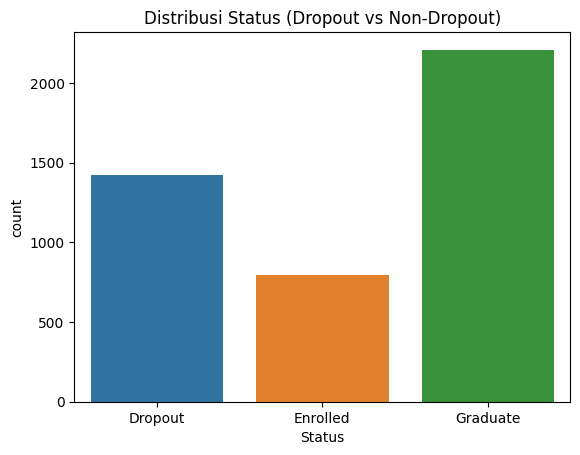

Status
Graduate    0.499322
Dropout     0.321203
Enrolled    0.179476
Name: proportion, dtype: float64

In [610]:
# distribusi status
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status (Dropout vs Non-Dropout)')
plt.show()

# proporsi
df['Status'].value_counts(normalize=True)

Jumlah mahasiswa dengan status Graduate merupakan yang terbanyak, diikuti oleh Dropout, dan Enrolled sebagai yang paling sedikit. Hal ini menunjukkan bahwa meskipun sebagian besar mahasiswa berhasil lulus, proporsi dropout masih cukup signifikan dan perlu menjadi perhatian utama institusi.

### 2. Performa Akademik

#### a. Semester 1 (approved)

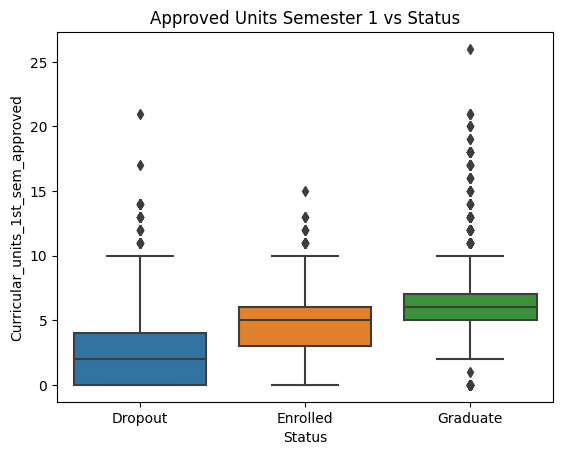

In [611]:
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Approved Units Semester 1 vs Status')
plt.show()

Mahasiswa dengan status Dropout memiliki jumlah mata kuliah yang disetujui (approved) paling rendah dibandingkan kategori lainnya. Sementara itu, mahasiswa yang berhasil Graduate memiliki jumlah mata kuliah lulus yang lebih tinggi. Hal ini menunjukkan bahwa performa akademik pada semester awal sangat berpengaruh terhadap keberlanjutan studi.

#### b. Semester 2 (approved)

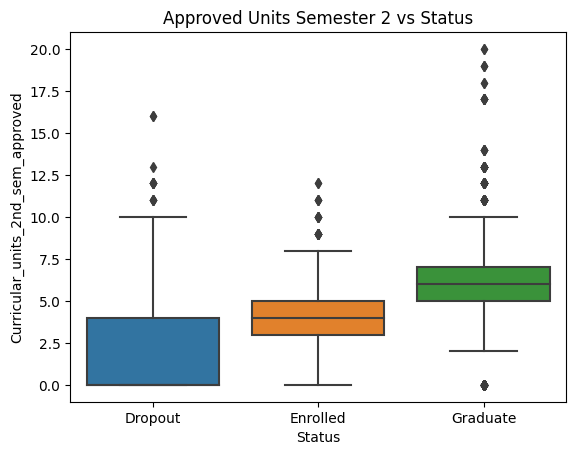

In [612]:
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_approved', data=df)
plt.title('Approved Units Semester 2 vs Status')
plt.show()

Pola yang sama terlihat pada semester 2, di mana mahasiswa Dropout memiliki jumlah mata kuliah lulus yang lebih sedikit dibandingkan Enrolled dan Graduate. Bahkan, perbedaan ini terlihat semakin jelas, menunjukkan bahwa kegagalan akademik yang berlanjut meningkatkan risiko dropout.

#### c. Grade Semester 1

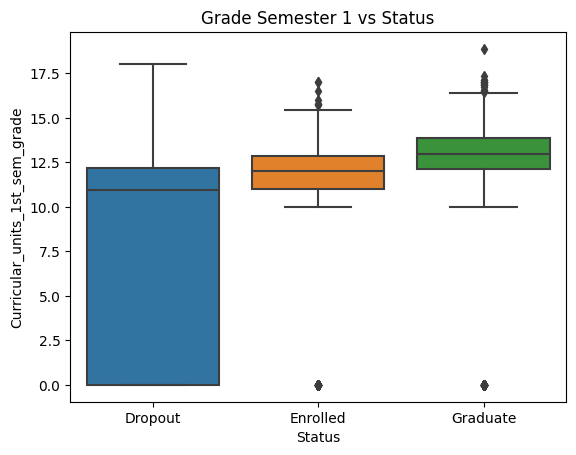

In [613]:
sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df)
plt.title('Grade Semester 1 vs Status')
plt.show()

Nilai rata-rata semester 1 mahasiswa Dropout cenderung lebih rendah dibandingkan mahasiswa yang Enrolled dan Graduate. Hal ini menunjukkan bahwa performa akademik sejak awal perkuliahan merupakan indikator penting dalam mendeteksi potensi dropout.

#### d. Grade Semester 2

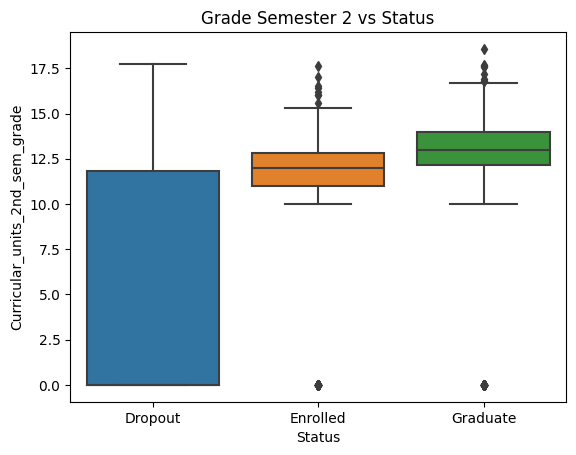

In [614]:
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_grade', data=df)
plt.title('Grade Semester 2 vs Status')
plt.show()

Perbedaan nilai semakin terlihat pada semester 2, di mana mahasiswa Graduate memiliki nilai rata-rata tertinggi, sedangkan Dropout memiliki distribusi nilai yang lebih rendah dan lebih bervariasi. Ini menunjukkan bahwa konsistensi performa akademik sangat berperan dalam keberhasilan studi.

### 3. Faktor Keuangan

#### a. Debtor

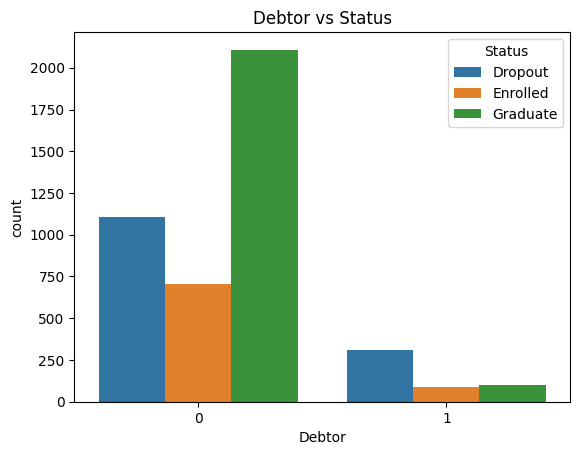

In [615]:
sns.countplot(x='Debtor', hue='Status', data=df)
plt.title('Debtor vs Status')
plt.show()

Mahasiswa dengan status Debtor (menunggak pembayaran) memiliki proporsi Dropout yang lebih tinggi dibandingkan yang tidak memiliki tunggakan. Hal ini mengindikasikan bahwa masalah finansial menjadi salah satu faktor penting yang memengaruhi keputusan mahasiswa untuk berhenti studi.

#### b. Tuition Fees

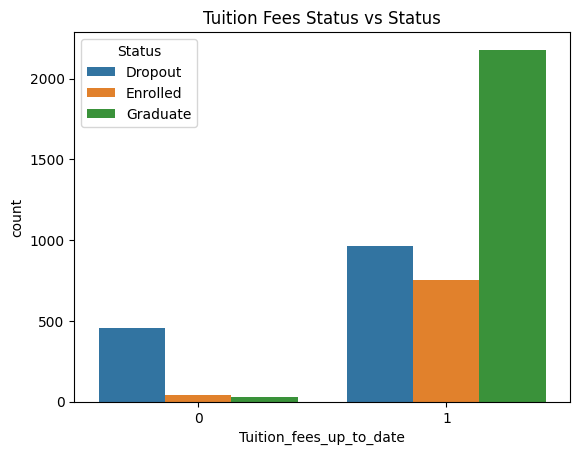

In [616]:
sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df)
plt.title('Tuition Fees Status vs Status')
plt.show()

Mahasiswa yang tidak membayar biaya kuliah tepat waktu cenderung lebih banyak berada pada kategori Dropout. Sebaliknya, mahasiswa yang memiliki status pembayaran lancar didominasi oleh kategori Graduate. Ini menunjukkan bahwa kepatuhan dalam pembayaran biaya kuliah berkorelasi kuat dengan keberhasilan akademik.

#### c. Scholarship

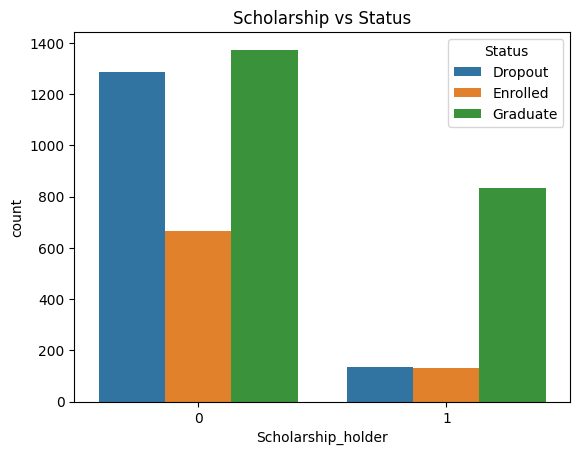

In [617]:
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title('Scholarship vs Status')
plt.show()

Mahasiswa yang menerima beasiswa cenderung lebih banyak berada pada kategori Graduate, sementara yang tidak menerima beasiswa memiliki proporsi dropout yang lebih tinggi. Hal ini menunjukkan bahwa dukungan finansial melalui beasiswa dapat membantu meningkatkan tingkat kelulusan.

### 4. Admission Grade

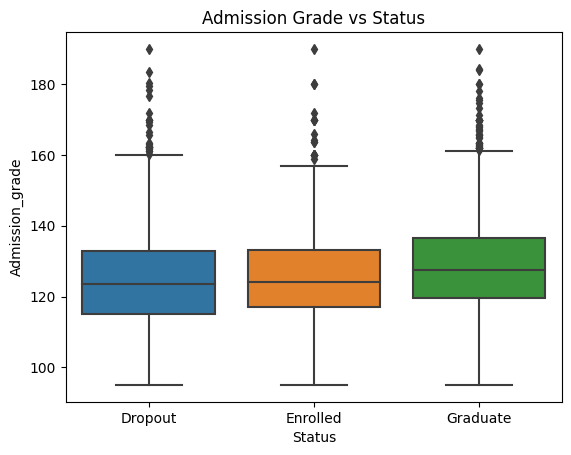

In [618]:
sns.boxplot(x='Status', y='Admission_grade', data=df)
plt.title('Admission Grade vs Status')
plt.show()

Meskipun tidak terdapat perbedaan yang signifikan, mahasiswa dengan nilai masuk (admission grade) yang lebih tinggi cenderung memiliki peluang lebih besar untuk Graduate, sedangkan mahasiswa dengan nilai masuk lebih rendah lebih berisiko mengalami Dropout. Ini menunjukkan bahwa kesiapan akademik awal memengaruhi performa selama studi.

### 5. Faktor Demografis

#### a. Age

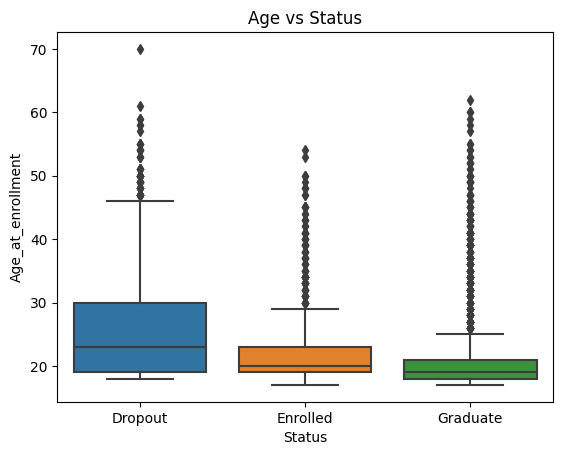

In [619]:
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title('Age vs Status')
plt.show()

Mahasiswa yang mengalami Dropout cenderung memiliki rentang usia yang lebih tinggi dibandingkan mahasiswa yang Graduate. Hal ini mengindikasikan bahwa mahasiswa dengan usia lebih tua mungkin menghadapi tantangan tambahan seperti pekerjaan atau tanggung jawab lain yang memengaruhi kelangsungan studi.

#### b. Gender

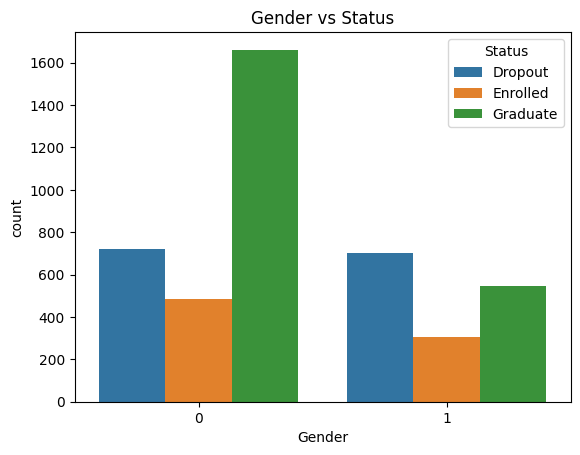

In [620]:
sns.countplot(x='Gender', hue='Status', data=df)
plt.title('Gender vs Status')
plt.show()

Distribusi gender menunjukkan adanya perbedaan jumlah antara laki-laki dan perempuan dalam setiap kategori status. Namun, pengaruh gender terhadap dropout tidak sekuat faktor akademik dan finansial, sehingga gender bukan merupakan faktor utama dalam menentukan risiko dropout.

### 6. Correlation Matrix

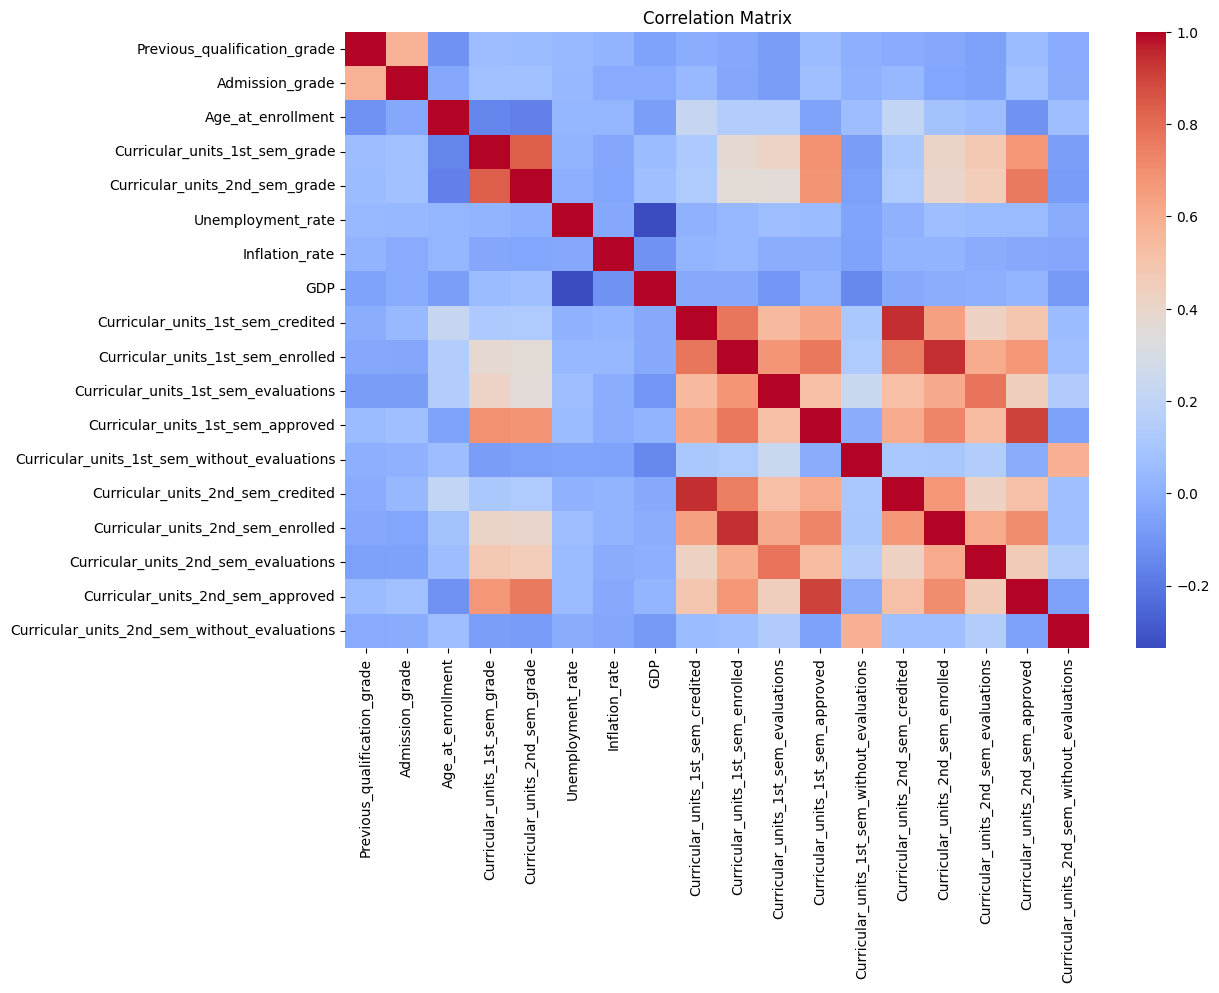

In [621]:
plt.figure(figsize=(12,8))
sns.heatmap(df[numerical_cols + count_cols].corr(), cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Berdasarkan matriks korelasi tersebut, berikut adalah beberapa insight utama yang dapat ditarik:

1. Korelasi Positif Kuat (Performa Berkelanjutan antara Semester 1 dan 2)

    - Blok berwarna merah gelap/terang di tengah dan bawah kanan menunjukkan bahwa kinerja akademik di semester 1 sangat menentukan kinerja di semester 2.
    - `Curricular_units_1st_sem_grade` dan `Curricular_units_2nd_sem_grade` memiliki korelasi positif yang sangat kuat. Artinya, mahasiswa yang mendapatkan nilai bagus di semester 1 cenderung mempertahankan nilai bagusnya di semester 2.
    - Demikian juga dengan jumlah unit yang diambil (`enrolled`), dievaluasi (`evaluations`), dan yang lulus (`approved`) antara semester 1 dan semester 2. Semuanya memiliki korelasi positif yang tinggi satu sama lain.

2. Korelasi Moderat (Kualifikasi Awal dan Kesuksesan Unit)

    - `Admission_grade` dan `Previous_qualification_grade` berkorelasi positif secara moderat (oranye). Ini menunjukkan bahwa nilai kualifikasi pendidikan sebelumnya memengaruhi nilai saat awal masuk/pendaftaran.
    - Terdapat korelasi positif moderat antara jumlah unit yang lulus (`approved`) dengan nilai akhir (`grade`) baik di semester 1 maupun 2. Mahasiswa yang lulus banyak unit mata kuliah cenderung selaras dengan nilai / IPK yang lebih tinggi.

3. Faktor Makroekonomi Tidak Berpengaruh Signifikan Terhadap Akademik

    - Variabel makroekonomi seperti `Unemployment_rate` (Tingkat Pengangguran), `Inflation_rate` (Inflasi), dan `GDP` sebagian besar berwarna biru muda saat disilangkan dengan variabel kinerja akademik (nilai dan unit lulus). Ini berarti metrik ekonomi tersebut tidak memiliki korelasi linear yang kuat terhadap performa studi mahasiswa.
    - Menariknya, terdapat korelasi negatif yang cukup terlihat (biru pekat) antara `Unemployment_rate` dan `GDP`, yang memang wajar secara ilmu ekonomi (saat GDP naik, pengangguran biasanya turun).

4. Usia Saat Mendaftar (Age at Enrollment)

    - `Age_at_enrollment` menunjukkan warna biru muda/sedang saat dikorelasikan dengan variabel `grade` dan `approved` di kedua semester. Ini mengindikasikan adanya korelasi negatif lemah. Secara sederhana, mahasiswa yang masuk di usia yang lebih tua cenderung memiliki tingkat partisipasi/kelulusan unit mata kuliah yang sedikit lebih rendah atau lebih rentan kesulitan akademik dibandingkan mahasiswa yang masuk fresh dari sekolah menengah.

### Gabungan

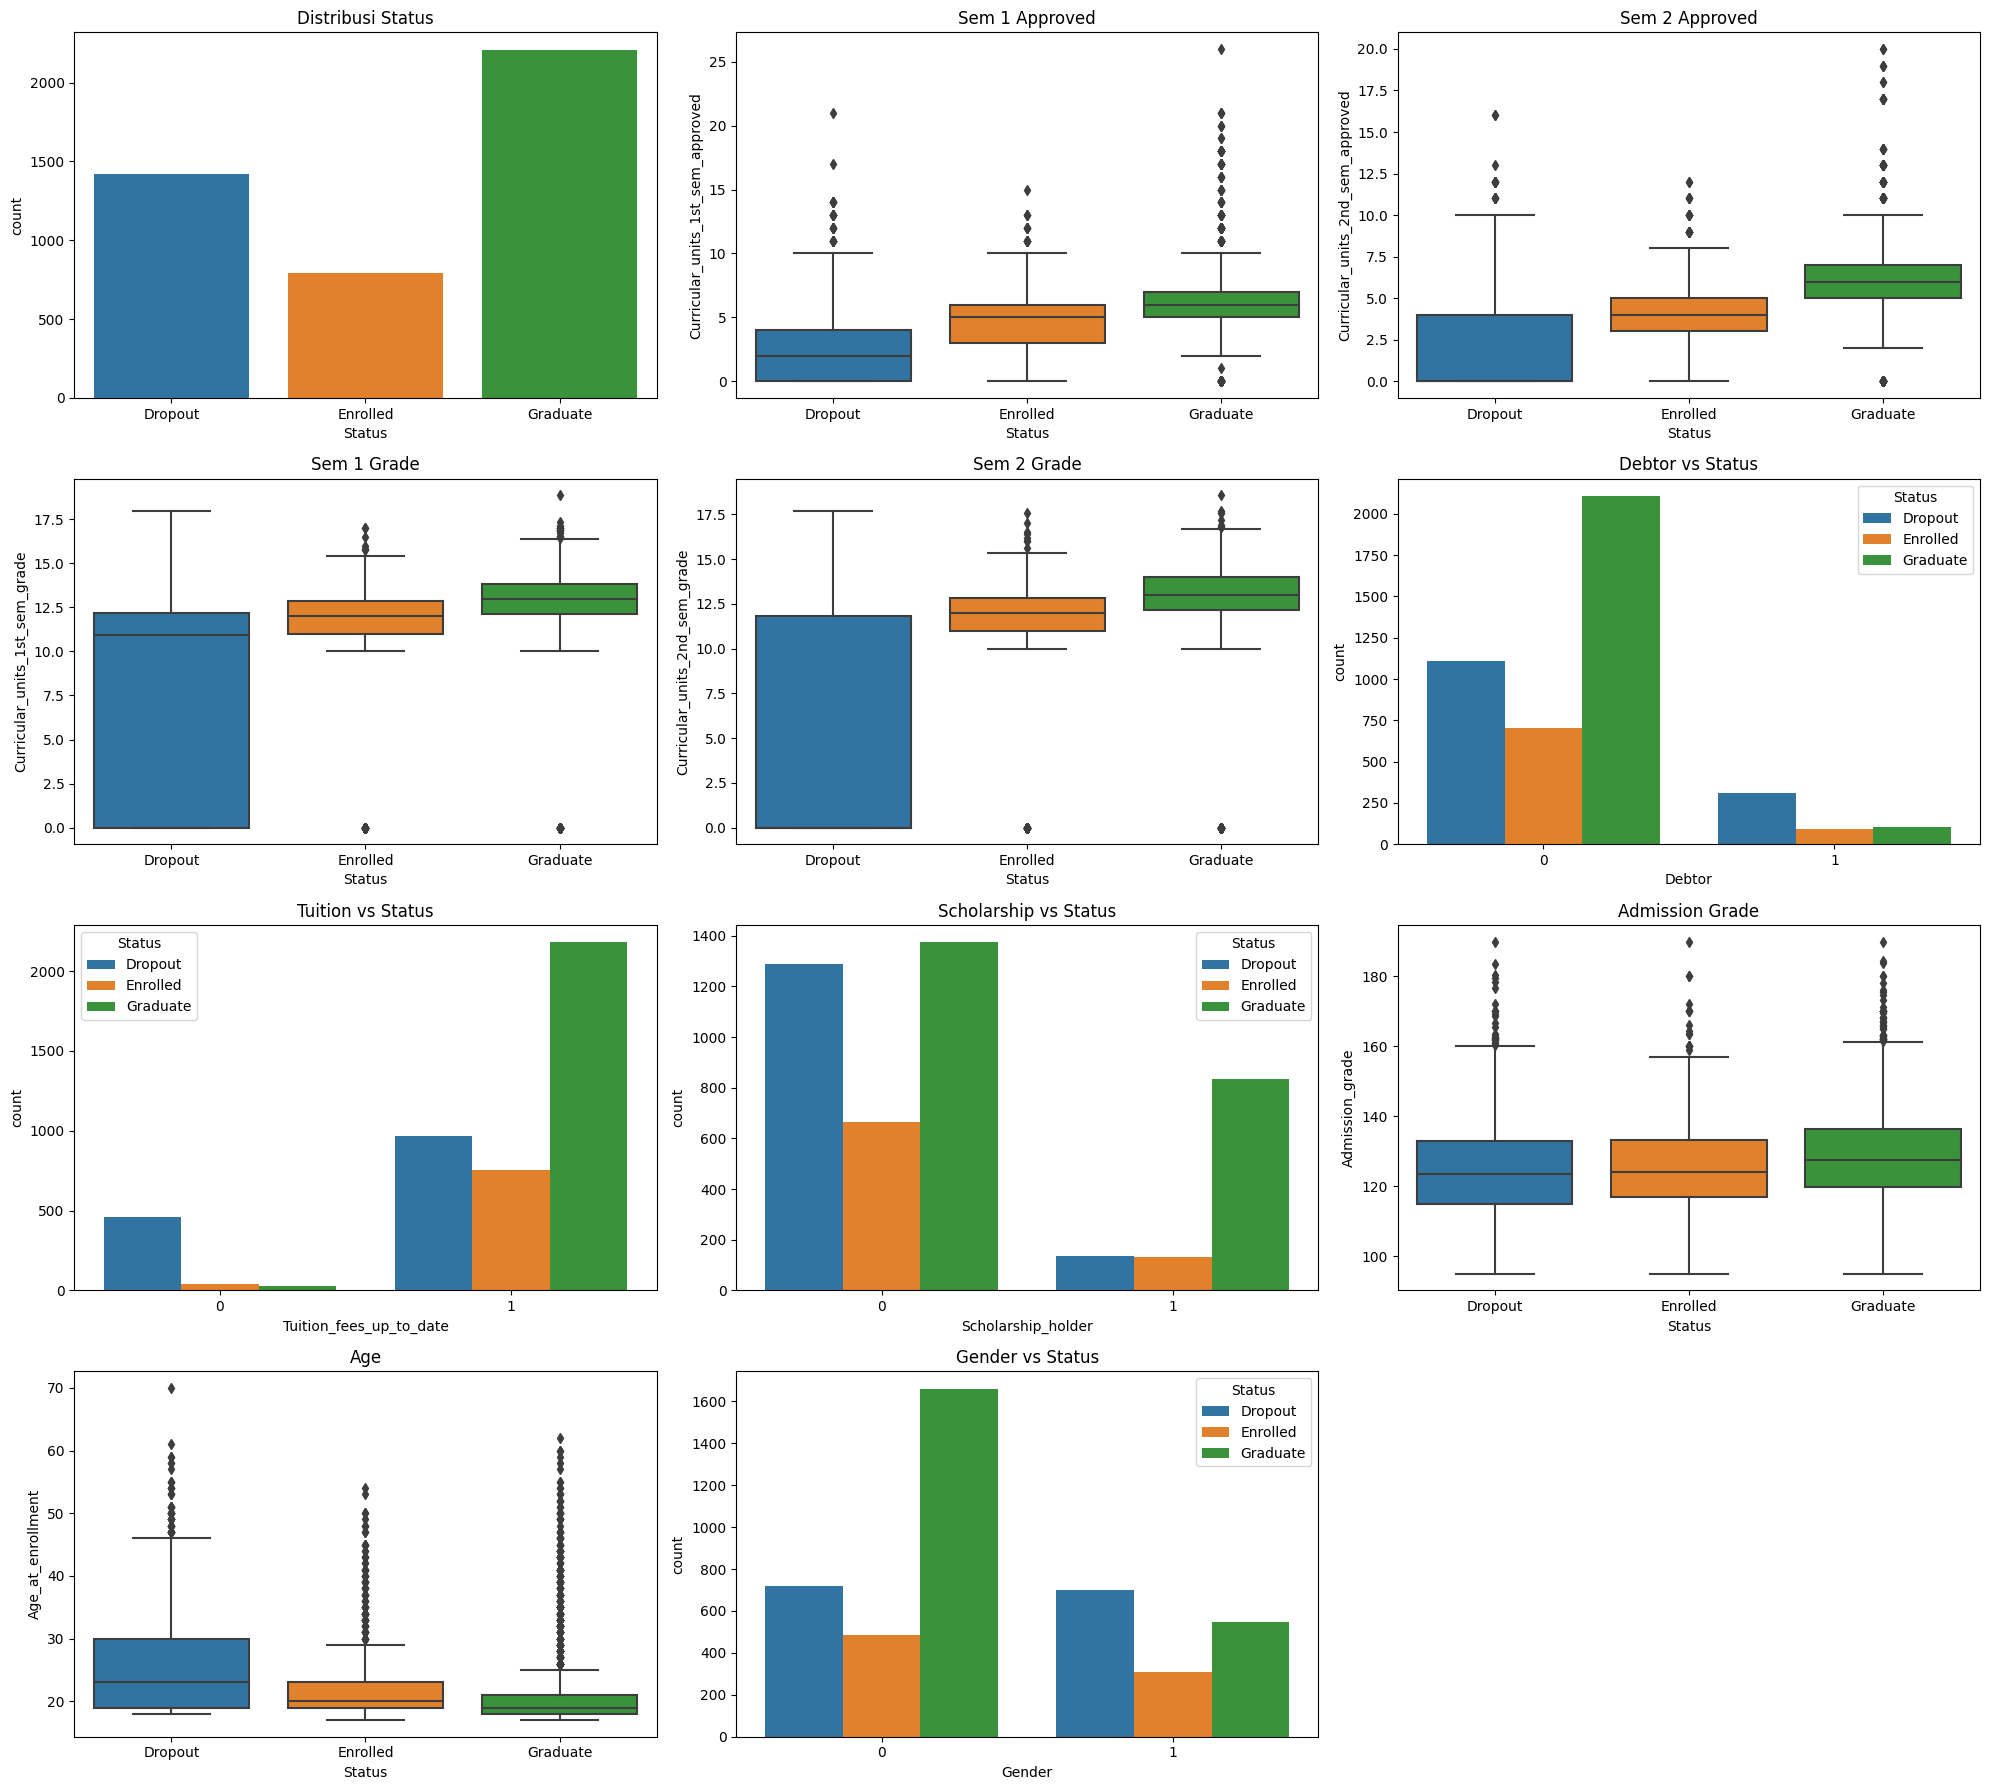

In [622]:
plt.figure(figsize=(20, 18))

# 1. Distribusi Status
plt.subplot(4, 3, 1)
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status')

# 2.a. Semester 1 Approved
plt.subplot(4, 3, 2)
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Sem 1 Approved')

# 2.b. Semester 2 Approved
plt.subplot(4, 3, 3)
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_approved', data=df)
plt.title('Sem 2 Approved')

# 2.c. Grade Semester 1
plt.subplot(4, 3, 4)
sns.boxplot(x='Status', y='Curricular_units_1st_sem_grade', data=df)
plt.title('Sem 1 Grade')

# 2.d. Grade Semester 2
plt.subplot(4, 3, 5)
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_grade', data=df)
plt.title('Sem 2 Grade')

# 3.a. Debtor
plt.subplot(4, 3, 6)
sns.countplot(x='Debtor', hue='Status', data=df)
plt.title('Debtor vs Status')

# 3.b. Tuition Fees
plt.subplot(4, 3, 7)
sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df)
plt.title('Tuition vs Status')

# 3.c. Scholarship
plt.subplot(4, 3, 8)
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title('Scholarship vs Status')

# 4. Admission Grade
plt.subplot(4, 3, 9)
sns.boxplot(x='Status', y='Admission_grade', data=df)
plt.title('Admission Grade')

# 5.a. Age
plt.subplot(4, 3, 10)
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.title('Age')

# 5.b. Gender
plt.subplot(4, 3, 11)
sns.countplot(x='Gender', hue='Status', data=df)
plt.title('Gender vs Status')

# # 6. Correlation Matrix
# plt.subplot(4, 3, 12)
# sns.heatmap(df.corr(), cmap='coolwarm')
# plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

Secara umum, distribusi dari mahasiswa dengan status "Enrolled" dan "Graduate" tidak jauh berbeda. Selain itu, tujuan dalam analisis ini adalah memprediksi mahasiswa yang akan Dropout sehingga dalam analisis ini dapat digabungkan menjadi satu kelompok. Oleh karena itu, permasalahan ini dapat diubah menjadi permasalahan klasifikasi biner (dropout vs tidak dropout).

## Data Preprocessing

In [ ]:
df_preprocessed = df.copy()

# Transformasi Target (Binary)
df_preprocessed['Status'] = df_preprocessed['Status'].map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})

# Pisahkan Fitur
X = df_preprocessed.drop('Status', axis=1)
y = df_preprocessed['Status']

# Label Encoding untuk High Cardinality
le_dict = {}
for col in high_card_cols:
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    # Pastikan data sudah di-fit ke LabelEncoder
    X[col] = le.fit_transform(X[col]) 
    le_dict[col] = le

# One-Hot Encoding untuk Low Cardinality
X = pd.get_dummies(X, columns=low_card_cols, drop_first=True)

# Simpan encoding info SETELAH get_dummies agar X_columns benar
encoding_info = {
    'low_card_cols': low_card_cols,
    'high_card_cols': high_card_cols,
    'le_dict': le_dict,
    'X_columns': list(X.columns) # Daftar kolom akhir setelah dapet dummy
}

# Scalling
scaler = StandardScaler()
X[numerical_cols + count_cols] = scaler.fit_transform(X[numerical_cols + count_cols])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [624]:
# simpan scaler and label ecoder
joblib.dump(scaler, "model/scaler.joblib")
joblib.dump(encoding_info, 'model/encoding_info.joblib')

['model/encoding_info.joblib']

## Modeling

In [625]:
SEED = 150

### 1. Logistic Regression

In [626]:
def objective_log(trial):
    C = trial.suggest_float('C', 1e-3, 10, log=True)

    model = LogisticRegression(
        C=C,
        max_iter=1000,
        random_state=SEED
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return recall_score(y_test, y_pred)

study_log = optuna.create_study(direction='maximize')
study_log.optimize(objective_log, n_trials=30)

# FINAL MODEL
best_log = LogisticRegression(
    **study_log.best_params,
    max_iter=1000,
    random_state=SEED
)

best_log.fit(X_train, y_train)
y_pred_log = best_log.predict(X_test)

print("Best Params Logistic:", study_log.best_params)

[I 2026-03-24 22:16:55,551] A new study created in memory with name: no-name-754566b5-6186-47ef-a1c4-5c0d69d459a7
[I 2026-03-24 22:16:55,695] Trial 0 finished with value: 0.6971830985915493 and parameters: {'C': 0.022600042015876533}. Best is trial 0 with value: 0.6971830985915493.
[I 2026-03-24 22:16:55,998] Trial 1 finished with value: 0.7359154929577465 and parameters: {'C': 4.429089114611398}. Best is trial 1 with value: 0.7359154929577465.
[I 2026-03-24 22:16:56,112] Trial 2 finished with value: 0.6866197183098591 and parameters: {'C': 0.012638420630266316}. Best is trial 1 with value: 0.7359154929577465.
[I 2026-03-24 22:16:56,349] Trial 3 finished with value: 0.7323943661971831 and parameters: {'C': 0.9684765417478142}. Best is trial 1 with value: 0.7359154929577465.
[I 2026-03-24 22:16:56,610] Trial 4 finished with value: 0.7323943661971831 and parameters: {'C': 2.269952016996055}. Best is trial 1 with value: 0.7359154929577465.
[I 2026-03-24 22:16:56,872] Trial 5 finished with

Best Params Logistic: {'C': 4.429089114611398}


### 2. Random Forest

In [627]:
def objective_rf(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 300),
        max_depth=trial.suggest_int('max_depth', 5, 20),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 5),
        class_weight=trial.suggest_categorical('class_weight', [None, 'balanced']),
        random_state=SEED,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return recall_score(y_test, y_pred)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=30)

# FINAL MODEL
best_rf = RandomForestClassifier(
    **study_rf.best_params,
    random_state=SEED,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

print("Best Params RF:", study_rf.best_params)

[I 2026-03-24 22:17:02,440] A new study created in memory with name: no-name-ac859ddf-f0d9-4f4e-8c0d-eee29a7b277a
[I 2026-03-24 22:17:02,702] Trial 0 finished with value: 0.721830985915493 and parameters: {'n_estimators': 145, 'max_depth': 14, 'min_samples_split': 8, 'min_samples_leaf': 4, 'class_weight': None}. Best is trial 0 with value: 0.721830985915493.
[I 2026-03-24 22:17:03,049] Trial 1 finished with value: 0.7288732394366197 and parameters: {'n_estimators': 195, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 3, 'class_weight': None}. Best is trial 1 with value: 0.7288732394366197.
[I 2026-03-24 22:17:03,329] Trial 2 finished with value: 0.7253521126760564 and parameters: {'n_estimators': 162, 'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 2, 'class_weight': None}. Best is trial 1 with value: 0.7288732394366197.
[I 2026-03-24 22:17:03,698] Trial 3 finished with value: 0.7746478873239436 and parameters: {'n_estimators': 211, 'max_depth': 14, 'min_sampl

Best Params RF: {'n_estimators': 255, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 5, 'class_weight': 'balanced'}


### 3. Gradient Boosting

In [628]:
def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2),
        max_depth=trial.suggest_int('max_depth', 3, 7),
        subsample=trial.suggest_float('subsample', 0.7, 1.0),
        random_state=SEED
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return recall_score(y_test, y_pred)

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(objective_gb, n_trials=30)

# FINAL MODEL
best_gb = GradientBoostingClassifier(
    **study_gb.best_params,
    random_state=SEED
)

best_gb.fit(X_train, y_train)
y_pred_gb = best_gb.predict(X_test)

print("Best Params GB:", study_gb.best_params)

[I 2026-03-24 22:17:13,713] A new study created in memory with name: no-name-f4da0566-bd87-4a71-9f99-3ed782d426d8
[I 2026-03-24 22:17:16,221] Trial 0 finished with value: 0.7640845070422535 and parameters: {'n_estimators': 290, 'learning_rate': 0.04384788757934937, 'max_depth': 4, 'subsample': 0.7248241795463983}. Best is trial 0 with value: 0.7640845070422535.
[I 2026-03-24 22:17:18,559] Trial 1 finished with value: 0.7676056338028169 and parameters: {'n_estimators': 242, 'learning_rate': 0.08029565696728677, 'max_depth': 4, 'subsample': 0.8378829289667267}. Best is trial 1 with value: 0.7676056338028169.
[I 2026-03-24 22:17:20,698] Trial 2 finished with value: 0.7640845070422535 and parameters: {'n_estimators': 132, 'learning_rate': 0.06669861354312612, 'max_depth': 6, 'subsample': 0.8814869653413191}. Best is trial 1 with value: 0.7676056338028169.
[I 2026-03-24 22:17:26,252] Trial 3 finished with value: 0.7605633802816901 and parameters: {'n_estimators': 257, 'learning_rate': 0.135

Best Params GB: {'n_estimators': 187, 'learning_rate': 0.1908497894652115, 'max_depth': 6, 'subsample': 0.9634432062786438}


### Simpan dalam folder model

In [629]:
joblib.dump(best_log, "model/logistic_model.joblib")
joblib.dump(best_rf, "model/random_forest_model.joblib")
joblib.dump(best_gb, "model/gradient_boosting_model.joblib")
print("Berhasil disimpan dalam folder model")

Berhasil disimpan dalam folder model


## Evaluation

### 1. Classification Report

In [630]:
print("Logistic Regression\n", classification_report(y_test, y_pred_log))
print("Random Forest\n", classification_report(y_test, y_pred_rf))
print("Gradient Boosting\n", classification_report(y_test, y_pred_gb))

Logistic Regression
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       601
           1       0.87      0.74      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.84      0.86       885
weighted avg       0.88      0.88      0.88       885

Random Forest
               precision    recall  f1-score   support

           0       0.91      0.89      0.90       601
           1       0.78      0.81      0.79       284

    accuracy                           0.87       885
   macro avg       0.84      0.85      0.85       885
weighted avg       0.87      0.87      0.87       885

Gradient Boosting
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       601
           1       0.83      0.78      0.81       284

    accuracy                           0.88       885
   macro avg       0.87      0.85      0.86       885
weighted avg       

### 2. Confussion Matrix

In [631]:
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

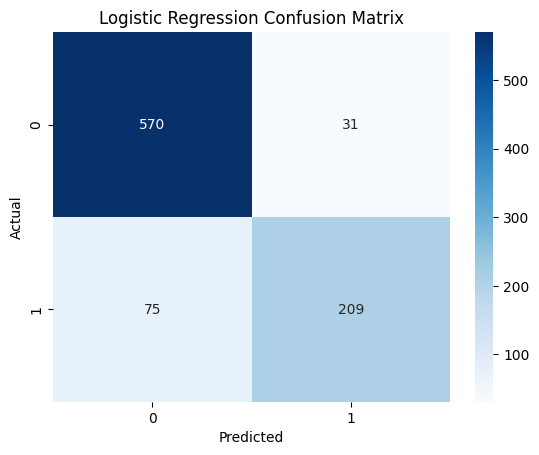

In [632]:
plot_cm(y_test, y_pred_log, "Logistic Regression Confusion Matrix")

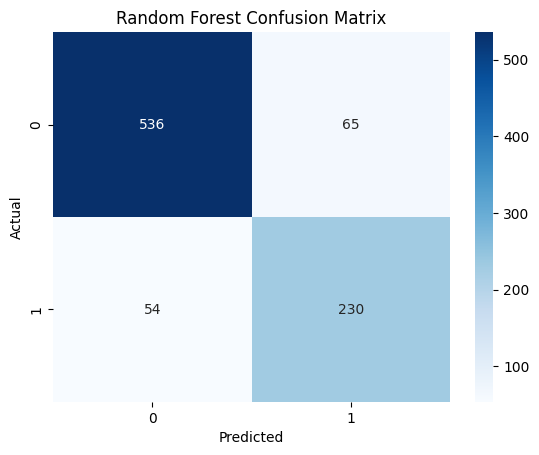

In [633]:
plot_cm(y_test, y_pred_rf, "Random Forest Confusion Matrix")

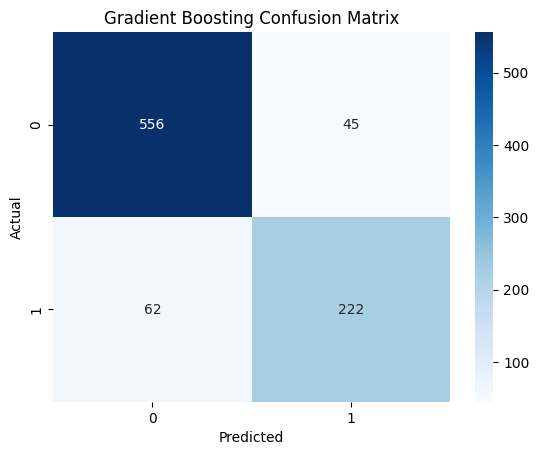

In [634]:
plot_cm(y_test, y_pred_gb, "Gradient Boosting Confusion Matrix")

### 3. ROC AUC

In [635]:
y_prob_log = best_log.predict_proba(X_test)[:,1]
roc_log = roc_auc_score(y_test, y_prob_log)

print("ROC AUC Score (Logistic Regression):", roc_log)

ROC AUC Score (Logistic Regression): 0.9289095638724192


In [636]:
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
roc_rf = roc_auc_score(y_test, y_prob_rf)

print("ROC AUC Score (Random Forest):", roc_rf)

ROC AUC Score (Random Forest): 0.921287291134494


In [637]:
y_prob_gb = best_gb.predict_proba(X_test)[:,1]
roc_gb = roc_auc_score(y_test, y_prob_gb)

print("ROC AUC Score (Gradient Boosting):", roc_gb)

ROC AUC Score (Gradient Boosting): 0.929378266269832


### 4. Tabel Evaluasi

In [638]:
# Kumpulkan semua model yang telah dilatih
models = {
    'Logistic Regression': best_log,
    'Random Forest': best_rf,
    'Gradient Boosting': best_gb
}

# List untuk menyimpan semua hasil metrik
evaluation_results = []

for name, model in models.items():
    # Hitung prediksi dan probabilitas prediksi untuk set test
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Hitung metrik evaluasi
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Tambahkan hasil ke list
    evaluation_results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    })

# Konversi list hasil menjadi DataFrame pandas
eval_df = pd.DataFrame(evaluation_results)

# Urutkan berdasarkan ROC-AUC atau F1 Score (opsional)
eval_df = eval_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

# Tampilkan tabel evaluasi
display(eval_df)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.831461,0.781690,0.805808,0.929378
1,Logistic Regression,0.870833,0.735915,0.797710,0.928910
2,Random Forest,0.779661,0.809859,0.794473,0.921287


Gradient Boosting dipilih karena memilik performa paling baik dibandingkan model lainnya, khususnya pada metrik F1 Score dan ROC-AUC.

### 5. Feature Importance

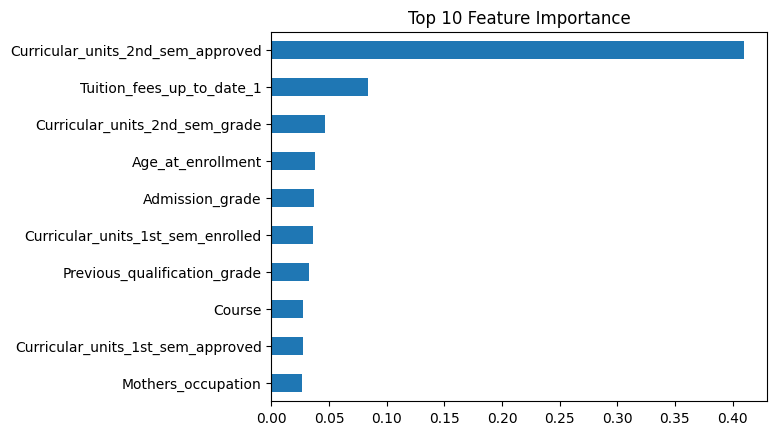

In [639]:
feature_importance = pd.Series(best_gb.feature_importances_, index=X.columns)
feature_importance.nlargest(10)[::-1].plot(kind='barh')
plt.title("Top 10 Feature Importance")
plt.show()

Dari Feature Importance didapatkan bahwa banyaknya jumlah mata kuliah semester 2 yang diambil dan disetujui (`Curricular_units_2nd_sem_approved`) menjadi faktor utama penentu status Dropout atau tidak.